In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Phase A: Model Loading and Architecture Verification

Based on the inspection of `notebooks/02_mobilevit_training.ipynb`, we use `timm` for the MobileViT architecture. We load the trained weights, freeze the backbone, and verify the feature extraction point.

In [5]:
import torch
import torch.nn as nn
import timm
from pathlib import Path
from google.colab import drive

# 1. Setup paths
WEIGHTS_DIR = Path('/content/drive/MyDrive/RI/weights/mobilevit/')
BEST_PATH = WEIGHTS_DIR / 'best_model.pth'
LATEST_PATH = WEIGHTS_DIR / 'latest_model.pth'

# 2. Instantiate Model exactly as in Milestone 2
model_name = 'mobilevit_xxs'
print(f"Instantiating {model_name}...")
model = timm.create_model(model_name, pretrained=False, num_classes=10)

# 3. Load Checkpoint
ckpt_path = BEST_PATH if BEST_PATH.exists() else LATEST_PATH
if not ckpt_path.exists():
    raise FileNotFoundError(f"No checkpoint found at {BEST_PATH} or {LATEST_PATH}")

print(f"Loading weights from {ckpt_path}...")
checkpoint = torch.load(ckpt_path, map_location="cpu")

if isinstance(checkpoint, dict):
    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint
else:
    state_dict = checkpoint

load_result = model.load_state_dict(state_dict, strict=True)

print("Missing keys:", load_result.missing_keys)
print("Unexpected keys:", load_result.unexpected_keys)

assert len(load_result.missing_keys) == 0
assert len(load_result.unexpected_keys) == 0
# 4. Freeze parameters
for param in model.parameters():
    param.requires_grad = False

# 5. Remove classification layer (timm MobileViT uses .head.fc)
# We replace the head with Identity to get features
print(model)

assert hasattr(model, "head"), "Expected timm MobileViT to have attribute 'head'."

model.head = nn.Identity()

model.eval()

# 6. Verification
print("-" * 50)
print(f"Model: {model_name}")
print(f"Head structure: {model.head}")

dummy_input = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    output = model(dummy_input)

print(f"Output feature shape: {output.shape}")
if output.ndim == 2:
    print("✓ Model already returns embeddings.")
elif output.ndim == 4:
    print("✓ Model returns feature maps. Pooling required.")
else:
    raise RuntimeError(f"Unexpected output shape: {output.shape}")
print("-" * 50)

Instantiating mobilevit_xxs...
Loading weights from /content/drive/MyDrive/RI/weights/mobilevit/best_model.pth...
Missing keys: []
Unexpected keys: []
ByobNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (stages): Sequential(
    (0): Sequential(
      (0): BottleneckBlock(
        (shortcut): Identity()
        (conv1_1x1): ConvNormAct(
          (conv): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
        )
        (conv2_kxk): ConvNormAct(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
 

## Phase B: Image Embedding Extraction

Following the verified output shape from Phase A, we extract 1D embeddings for the entire dataset using the specific preprocessing and data structure from Milestone 2.

In [6]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.nn.functional as F
from tqdm.auto import tqdm
from pathlib import Path
import torch
import os

# 1. Dataset Extraction
# Search for the zip file in the RI directory as requested in the context
ZIP_PATH = "/content/drive/MyDrive/RI/Dataset/state-farm-distracted-driver-detection.zip"
DATA_DIR = Path('/content/dataset')

if not (DATA_DIR / 'driver_imgs_list.csv').exists():
    if not os.path.exists(ZIP_PATH):
         print(f"Searching for dataset zip...")
         # Fallback search if the direct path fails
         search_results = !find /content/drive/MyDrive -name "state-farm-distracted-driver-detection.zip" 2>/dev/null
         if search_results:
             ZIP_PATH = search_results[0]
             print(f"Found zip at: {ZIP_PATH}")
         else:
             raise FileNotFoundError("Could not find state-farm-distracted-driver-detection.zip in Google Drive.")

    print(f"Unzipping dataset from {ZIP_PATH}...")
    !mkdir -p {DATA_DIR}
    !unzip -q "{ZIP_PATH}" -d {DATA_DIR}
    print("Unzip complete.")
else:
    print("Dataset already extracted at /content/dataset")

# 2. Dataset Class from Milestone 2
class MobileViTDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.root_dir / 'train' / row['classname'] / row['img']
        if not img_path.exists():
            img_path = self.root_dir / 'imgs' / 'train' / row['classname'] / row['img']

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, row['img'], row['classname'], row['subject']

# 3. Configuration and Preprocessing
CSV_PATH = DATA_DIR / 'driver_imgs_list.csv'
df = pd.read_csv(CSV_PATH)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

dataset = MobileViTDataset(df, DATA_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)

# 4. Extraction Loop
all_embeddings = []
metadata = []

print(f"Extracting embeddings for {len(dataset)} images on {device}...")

with torch.no_grad():
    for imgs, names, labels, subjects in tqdm(loader):
        imgs = imgs.to(device)
        features = model(imgs)

        if len(features.shape) == 4:
            features = F.adaptive_avg_pool2d(features, (1, 1)).flatten(1)

        all_embeddings.append(features.cpu().numpy())

        for i in range(len(names)):
            metadata.append({
                'img': names[i],
                'label': labels[i],
                'subject': subjects[i]
            })

# 5. Save and Validate
final_embeddings = np.concatenate(all_embeddings, axis=0)
metadata_df = pd.DataFrame(metadata)

np.save('image_embeddings.npy', final_embeddings)
metadata_df.to_parquet('embedding_metadata.parquet', index=False)

print("\n--- Phase B Validation ---")
print(f"Number of images: {len(final_embeddings)}")
print(f"Embedding dimension: {final_embeddings.shape[1]}")
print(f"Tensor shape: {final_embeddings.shape}")
print(f"Memory usage: {final_embeddings.nbytes / (1024**2):.2f} MB")

Unzipping dataset from /content/drive/MyDrive/RI/Dataset/state-farm-distracted-driver-detection.zip...
Unzip complete.
Extracting embeddings for 22424 images on cuda...


  0%|          | 0/351 [00:00<?, ?it/s]


--- Phase B Validation ---
Number of images: 22424
Embedding dimension: 320
Tensor shape: (22424, 320)
Memory usage: 27.37 MB


## Phase C: Feature Fusion and Multimodal Preprocessing

In this phase, we combine the 320D visual embeddings from MobileViT with handcrafted geometric features (landmarks, EAR, gaze).

**Key constraints applied:**
1. **Leakage Prevention:** `StandardScaler` is fitted strictly on training subjects.
2. **Feature Preservation:** All specified landmarks and geometric signals are kept, including NaNs.
3. **Concatenation:** Final vectors will combine visual and geometric information.

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import os

# 1. Define paths
EMBED_PATH = '/content/RI/image_embeddings.npy'
META_PATH = '/content/RI/embedding_metadata.parquet'
LANDMARK_PATH = '/content/drive/MyDrive/RI/landmarks.csv'

# Load Data
embeddings = np.load(EMBED_PATH)
metadata = pd.read_parquet(META_PATH)
landmarks_df = pd.read_csv(LANDMARK_PATH)

# 2. Resolve Merge Key
if 'image_name' in landmarks_df.columns:
    landmarks_df = landmarks_df.rename(columns={'image_name': 'img'})

visual_df = metadata.copy()
visual_df['embedding'] = list(embeddings)

# Merge visual embeddings with geometric landmarks on image name
# Use suffixes to handle the 'subject' and 'label' columns existing in both
fused_df = pd.merge(visual_df, landmarks_df, on='img', how='left', suffixes=('', '_drop'))

# Drop redundant columns from merge
cols_to_drop = [c for c in fused_df.columns if c.endswith('_drop')]
fused_df = fused_df.drop(columns=cols_to_drop)

# 3. Define Handcrafted Feature Columns as per Task
numeric_geo_cols = [
    'face_xmin', 'face_ymin', 'face_width', 'face_height', # Bounding box
    'pitch', 'yaw', 'roll',                               # Head pose
    'gaze_x', 'gaze_y',                                   # Gaze
    'ear_avg', 'eye_open_left', 'eye_open_right'          # EAR/Openness
]

# 4. Subject-based Scaling (Prevent Leakage)
all_subjects = fused_df['subject'].unique()
train_subjects = all_subjects[:int(0.8 * len(all_subjects))]

scaler = StandardScaler()
train_mask = fused_df['subject'].isin(train_subjects)

# Fit on training data and transform (StandardScaler preserves NaNs)
scaler.fit(fused_df.loc[train_mask, numeric_geo_cols])
fused_df.loc[:, numeric_geo_cols] = scaler.transform(fused_df[numeric_geo_cols])

# 5. Final Concatenation (320D Visual + Numeric Geometric)
def create_fusion_vector(row):
    vis_vec = row['embedding']
    geo_vec = row[numeric_geo_cols].values.astype(np.float32)
    return np.concatenate([vis_vec, geo_vec])

fused_features = np.stack(fused_df.apply(create_fusion_vector, axis=1).values)

# 6. Save Outputs
np.save('fusion_features.npy', fused_features)
np.save('fusion_labels.npy', fused_df['label'].values)
np.save('fusion_subjects.npy', fused_df['subject'].values)
fused_df.to_parquet('fusion_dataframe.parquet', index=False)

# 7. Validation Output
print("--- Phase C Validation Report ---")
print(f"Fused Feature Dimension: {fused_features.shape[1]} (320 visual + {len(numeric_geo_cols)} geometric)")
print(f"Total Samples: {len(fused_features)}")
print(f"NaN count in geometric features: {fused_df[numeric_geo_cols].isna().sum().sum()}")
print(f"Memory usage: {fused_features.nbytes / (1024**2):.2f} MB")

idx = np.random.randint(0, len(fused_features))
print(f"\nRandom Sample index {idx} (Subject: {fused_df.iloc[idx]['subject']}):")
print(f"Fused vector starts with: {fused_features[idx][:3]}")

--- Phase C Validation Report ---
Fused Feature Dimension: 332 (320 visual + 12 geometric)
Total Samples: 22424
NaN count in geometric features: 169188
Memory usage: 28.40 MB

Random Sample index 475 (Subject: p002):
Fused vector starts with: [-0.16182104 -0.26120713 -0.21263663]


## Phase D: Multimodal Feature Analysis and Visualization

This phase focuses on validating the fused feature space (332D) created in Phase C. We utilize dimensionality reduction and statistical plotting to ensure the features are discriminative and that the normalization/NaN handling was performed correctly.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import json
from pathlib import Path

# 1. Setup Output Directory
OUTPUT_DIR = Path('outputs/analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load Phase C Data - Added allow_pickle=True for string arrays
fused_features = np.load('fusion_features.npy')
fused_labels = np.load('fusion_labels.npy', allow_pickle=True)
fused_subjects = np.load('fusion_subjects.npy', allow_pickle=True)
fused_df = pd.read_parquet('fusion_dataframe.parquet')

# Handle NaNs for Visualization (Impute with 0 for PCA/t-SNE only)
vis_features = np.nan_to_num(fused_features)

print(f"Analyzing {fused_features.shape[0]} samples with {fused_features.shape[1]} dimensions.")

Analyzing 22424 samples with 332 dimensions.


Running PCA and t-SNE (this may take a minute)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


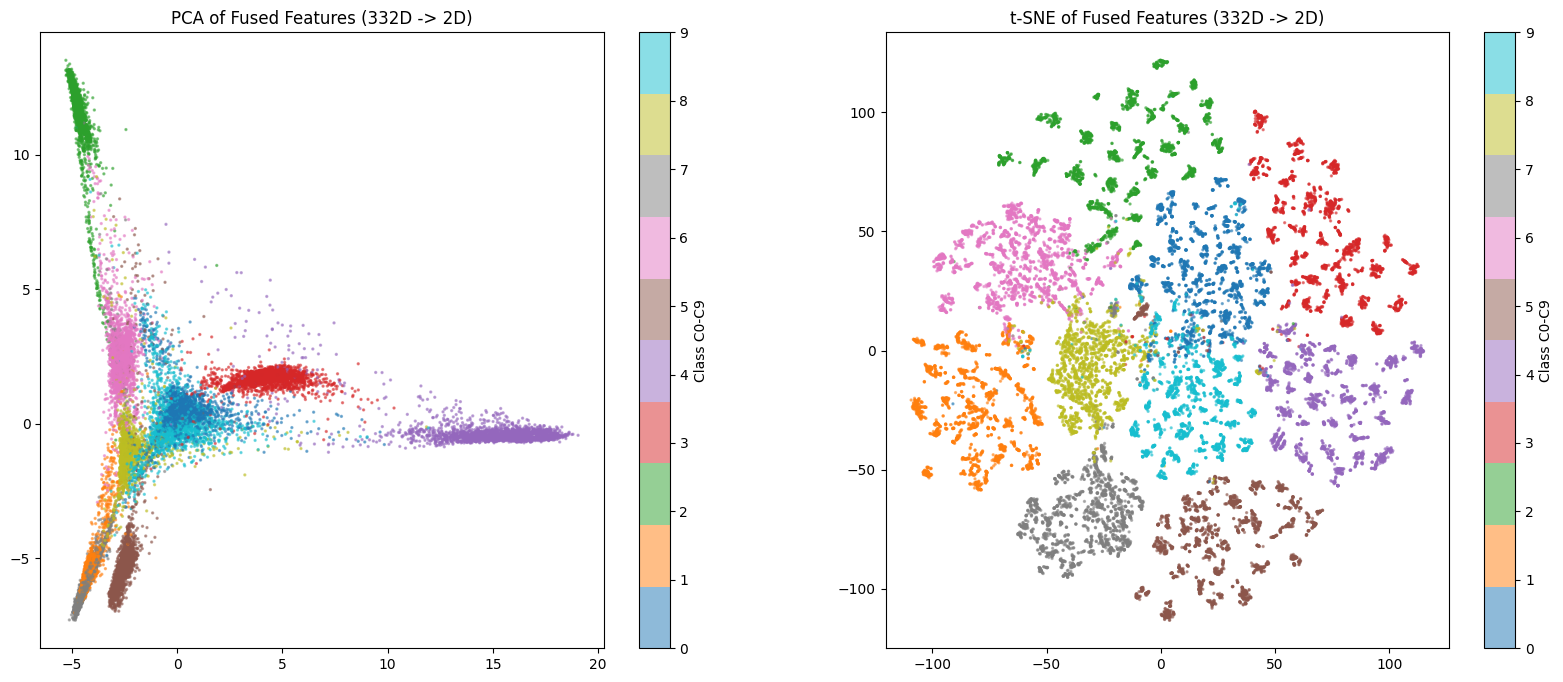

In [9]:
# 2. Dimensionality Reduction (PCA & t-SNE)
print("Running PCA and t-SNE (this may take a minute)...")

# PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(vis_features)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(vis_features)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Convert labels to categorical codes for coloring
label_codes = pd.Categorical(fused_labels).codes

# PCA Plot
scatter1 = ax1.scatter(pca_results[:, 0], pca_results[:, 1], c=label_codes, cmap='tab10', alpha=0.5, s=2)
ax1.set_title('PCA of Fused Features (332D -> 2D)')
plt.colorbar(scatter1, ax=ax1, label='Class C0-C9')

# t-SNE Plot
scatter2 = ax2.scatter(tsne_results[:, 0], tsne_results[:, 1], c=label_codes, cmap='tab10', alpha=0.5, s=2)
ax2.set_title('t-SNE of Fused Features (332D -> 2D)')
plt.colorbar(scatter2, ax=ax2, label='Class C0-C9')

plt.savefig(OUTPUT_DIR / 'pca_tsne_visualization.png')
plt.show()

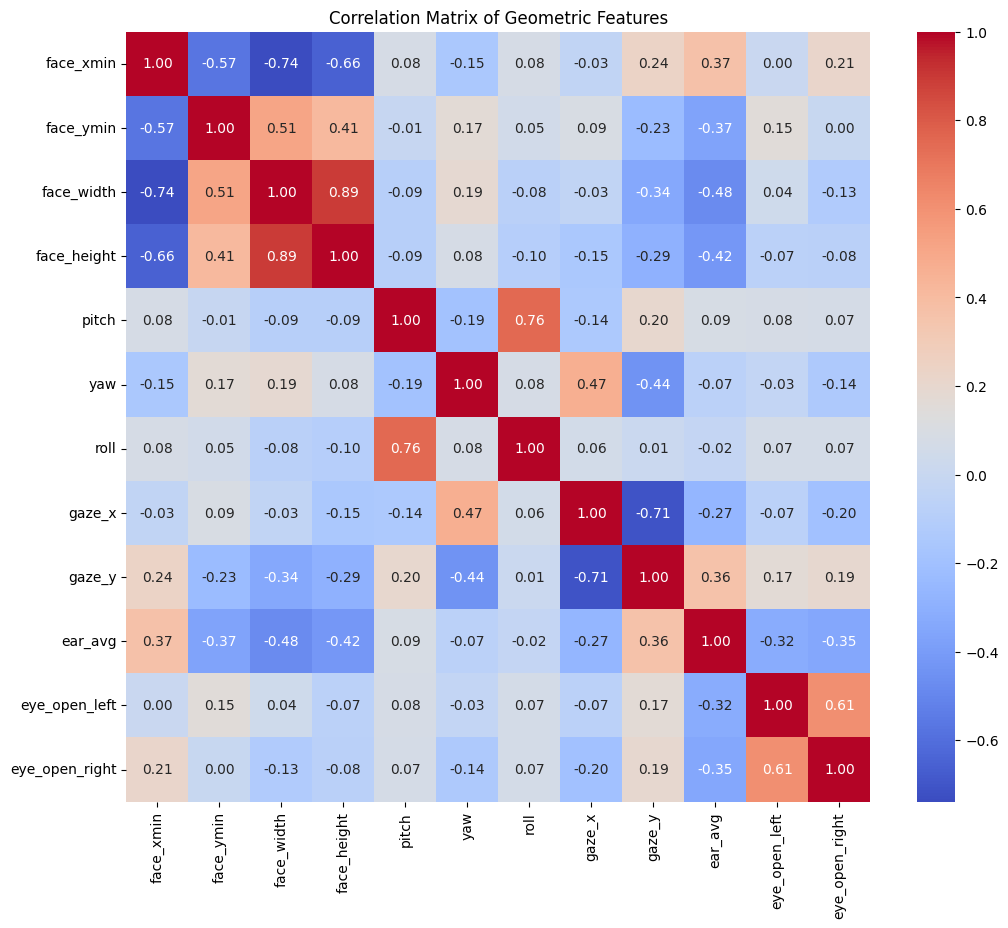

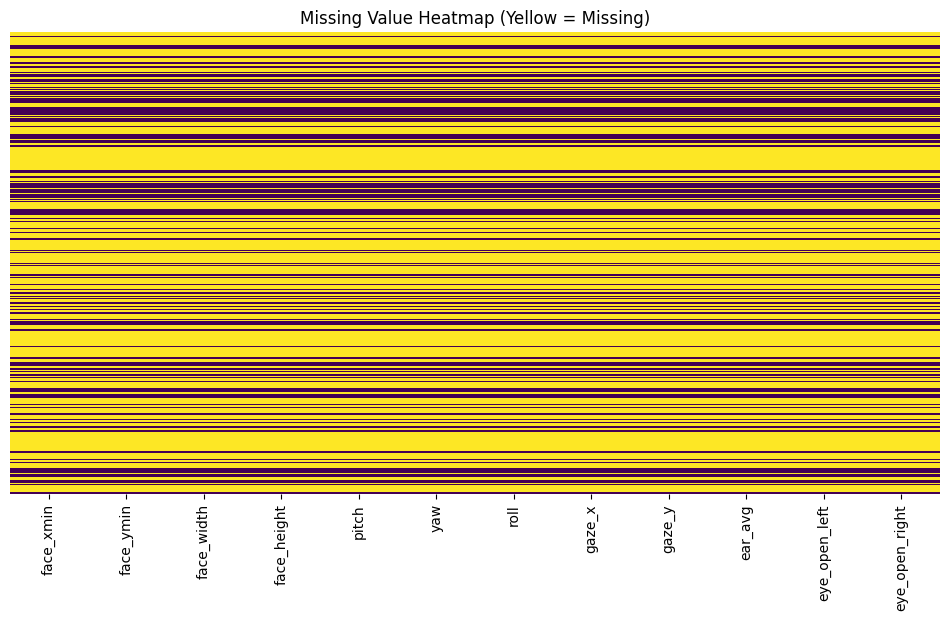

In [10]:
# 3. Correlation and Missing Values Analysis
numeric_geo_cols = ['face_xmin', 'face_ymin', 'face_width', 'face_height', 'pitch', 'yaw', 'roll', 'gaze_x', 'gaze_y', 'ear_avg', 'eye_open_left', 'eye_open_right']

plt.figure(figsize=(12, 10))
sns.heatmap(fused_df[numeric_geo_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Geometric Features')
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png')
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(fused_df[numeric_geo_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap (Yellow = Missing)')
plt.savefig(OUTPUT_DIR / 'missing_values.png')
plt.show()

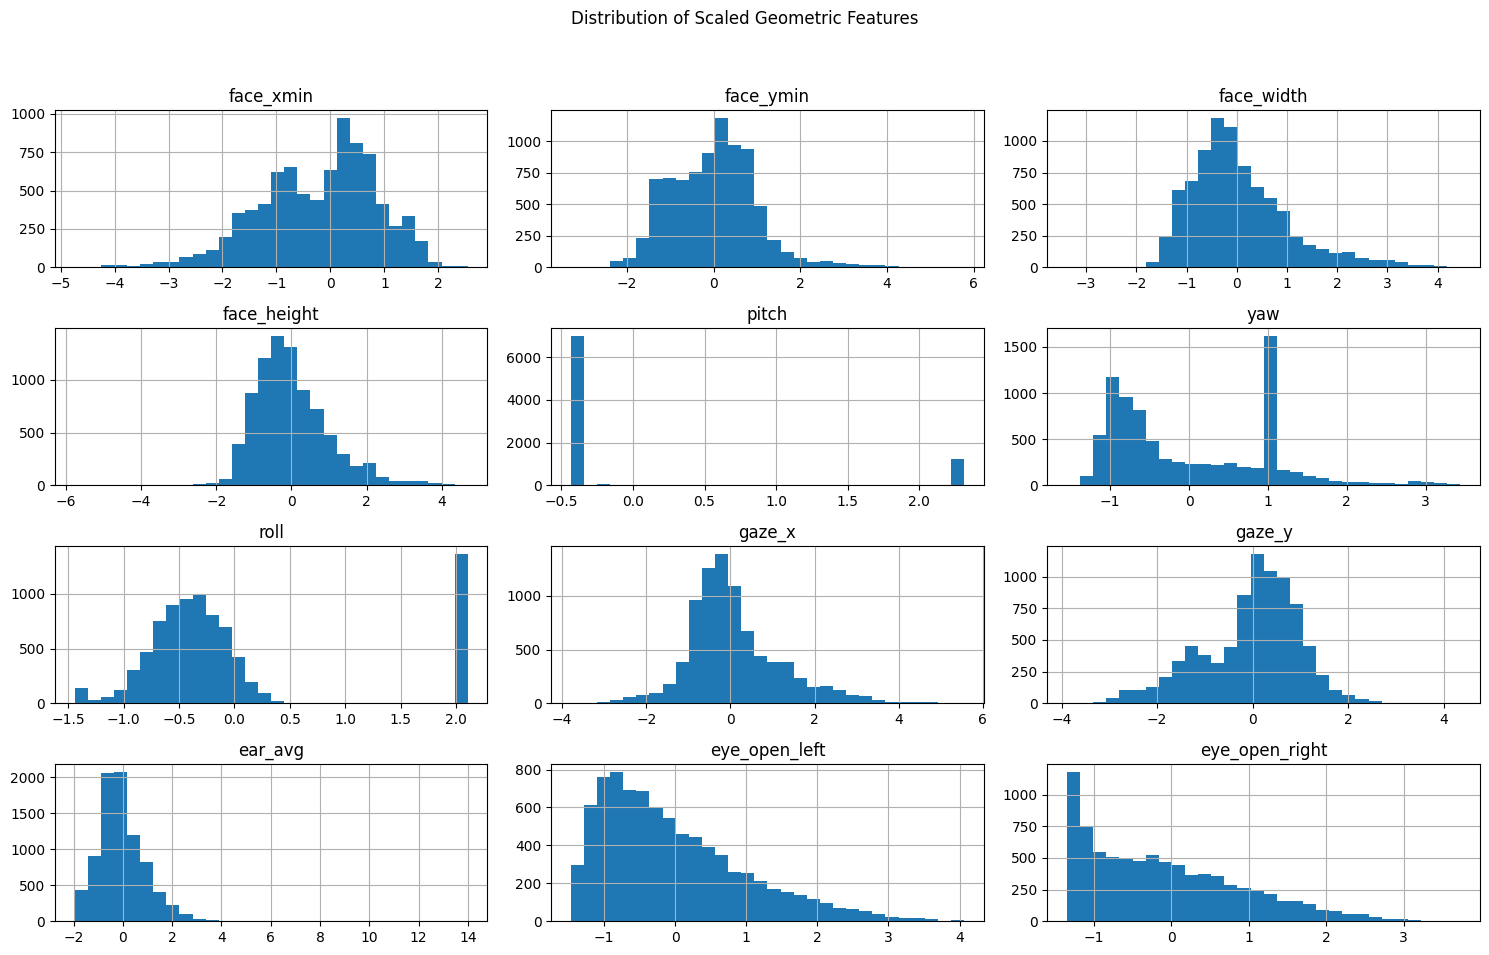


--- Phase D Validation ---
Metadata saved to outputs/analysis/fusion_metadata.json
All visualizations saved to outputs/analysis


In [11]:
# 4. Feature Histograms and Metadata Export
numeric_geo_cols = ['face_xmin', 'face_ymin', 'face_width', 'face_height', 'pitch', 'yaw', 'roll', 'gaze_x', 'gaze_y', 'ear_avg', 'eye_open_left', 'eye_open_right']

fused_df[numeric_geo_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Scaled Geometric Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(OUTPUT_DIR / 'histogram.png')
plt.show()

# Save Analysis Metadata
metadata_summary = {
    "total_samples": int(fused_features.shape[0]),
    "feature_dimension": int(fused_features.shape[1]),
    "classes": [str(x) for x in np.unique(fused_labels)],
    "subjects": [str(x) for x in np.unique(fused_subjects)],
    "nan_total": int(fused_df[numeric_geo_cols].isna().sum().sum()),
    "pca_explained_variance": pca.explained_variance_ratio_.tolist()
}

with open(OUTPUT_DIR / 'fusion_metadata.json', 'w') as f:
    json.dump(metadata_summary, f, indent=4)

print(f"\n--- Phase D Validation ---")
print(f"Metadata saved to {OUTPUT_DIR / 'fusion_metadata.json'}")
print(f"All visualizations saved to {OUTPUT_DIR}")

In [13]:
print("--- Milestone 4 Completed ---")

--- Milestone 4 Completed ---
